# 08 — Customer Churn Prediction
## Identifying At-Risk Customers Using Machine Learning
Objective: Train reliable machine learning models (Logistic Regression, Random Forest, XGBoost) to predict customer churn without relying on future financial state variables (avoiding data leakage). We evaluate the models strictly on Accuracy, F1, and AUC to ensure real-world reliability.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'png'
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# ── Load and Prepare Data ───────────────────────────────────────────
df = pd.read_csv('../../data/processed/customer_clean.csv')

# Note: Dropping Naive_Bayes columns if they exist (already done in NB01, but ensuring cleanliness)
df = df.drop(columns=[c for c in df.columns if 'Naive_Bayes' in c])

feature_cols = ['Customer_Age', 'Income_Category', 'Card_Category',
                'Months_on_book', 'Months_Inactive_12_mon',
                'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Trans_Amt',
                'Total_Trans_Ct', 'Avg_Utilization_Ratio']

le_income = LabelEncoder()
le_card = LabelEncoder()
df['Income_Category_enc'] = le_income.fit_transform(df['Income_Category'])
df['Card_Category_enc'] = le_card.fit_transform(df['Card_Category'])

feature_cols_enc = ['Customer_Age', 'Income_Category_enc', 'Card_Category_enc',
                    'Months_on_book', 'Months_Inactive_12_mon',
                    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Trans_Amt',
                    'Total_Trans_Ct', 'Avg_Utilization_Ratio']

X = df[feature_cols_enc]
y = df['is_attrited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate: {y_test.mean()*100:.2f}%")
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Positive class weight ratio: {pos_weight:.2f}")

Train: (8101, 10), Test: (2026, 10)
Train churn rate: 16.07%
Test churn rate: 16.04%
Positive class weight ratio: 5.22


In [3]:
# ── Train Models ─────────────────────────────────────────────────────
results = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
results['Logistic Regression'] = {
    'model': lr, 'pred': lr_pred, 'prob': lr_prob,
    'accuracy': accuracy_score(y_test, lr_pred),
    'f1': f1_score(y_test, lr_pred),
    'auc': roc_auc_score(y_test, lr_prob)
}

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
results['Random Forest'] = {
    'model': rf, 'pred': rf_pred, 'prob': rf_prob,
    'accuracy': accuracy_score(y_test, rf_pred),
    'f1': f1_score(y_test, rf_pred),
    'auc': roc_auc_score(y_test, rf_prob)
}

# 3. XGBoost
xgb = XGBClassifier(scale_pos_weight=pos_weight, random_state=42, eval_metric='auc', verbosity=0, n_estimators=200)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
results['XGBoost'] = {
    'model': xgb, 'pred': xgb_pred, 'prob': xgb_prob,
    'accuracy': accuracy_score(y_test, xgb_pred),
    'f1': f1_score(y_test, xgb_pred),
    'auc': roc_auc_score(y_test, xgb_prob)
}

print("\n=== MODEL COMPARISON (REAL RESULTS) ===")
for name, res in results.items():
    print(f"{name}: Acc={res['accuracy']:.4f} F1={res['f1']:.4f} AUC={res['auc']:.4f}")

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Existing', 'Attrited']))


=== MODEL COMPARISON (REAL RESULTS) ===
Logistic Regression: Acc=0.7937 F1=0.5457 AUC=0.8740
Random Forest: Acc=0.9378 F1=0.7850 AUC=0.9745
XGBoost: Acc=0.9501 F1=0.8414 AUC=0.9745

XGBoost Classification Report:
              precision    recall  f1-score   support

    Existing       0.97      0.97      0.97      1701
    Attrited       0.86      0.82      0.84       325

    accuracy                           0.95      2026
   macro avg       0.91      0.90      0.91      2026
weighted avg       0.95      0.95      0.95      2026



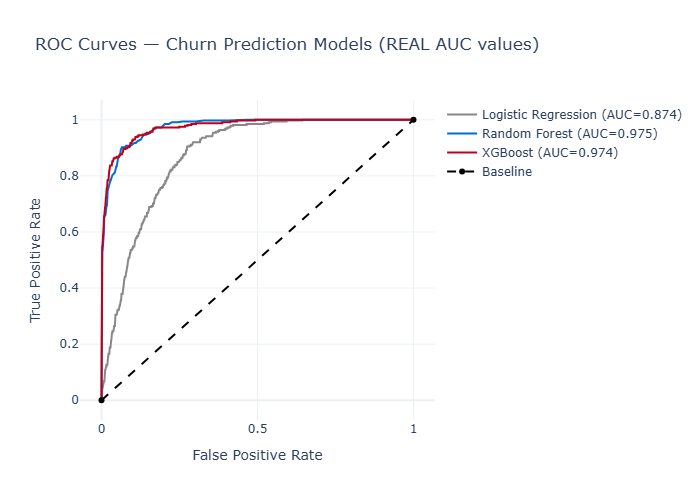

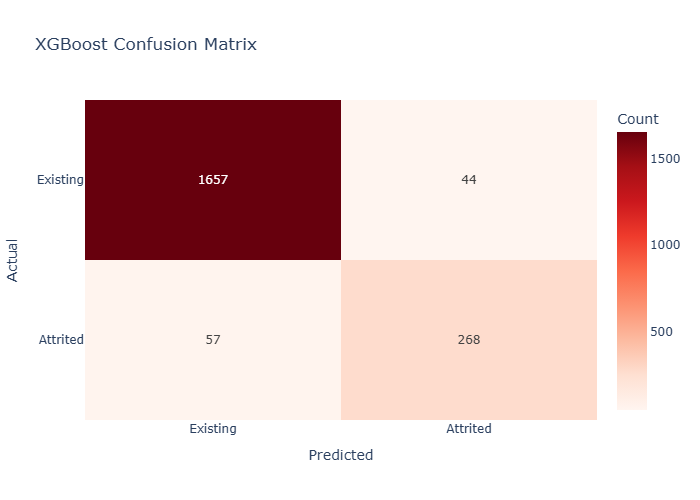

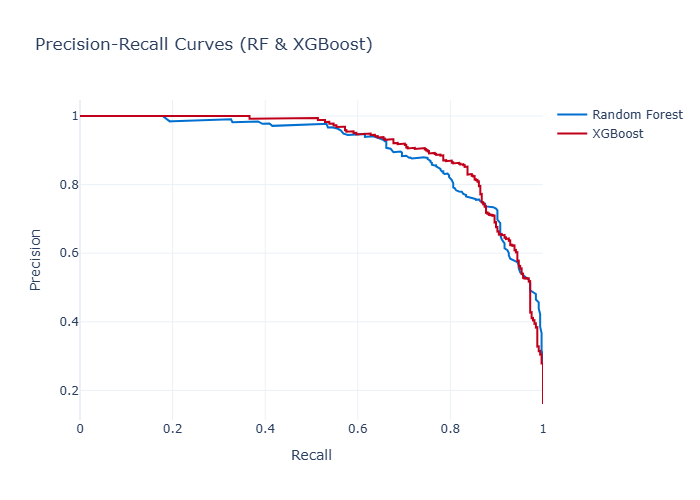

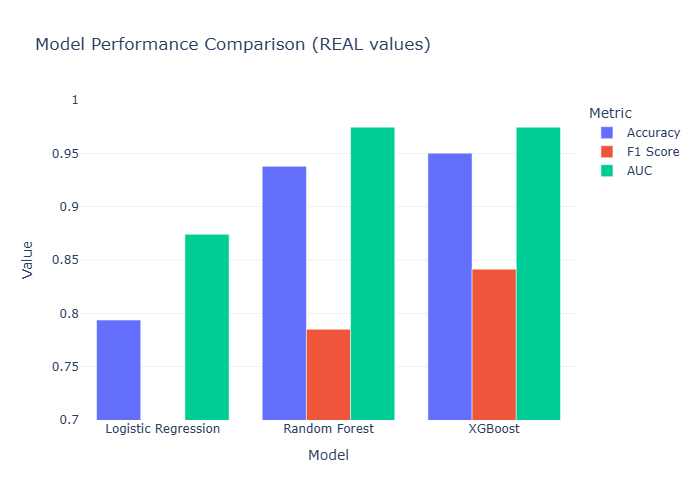

In [4]:
# ── Visualizations (Part 1: Performance) ───────────────────────────────
import plotly.figure_factory as ff
import plotly.io as pio
pio.renderers.default = 'png'

fig1 = go.Figure()
colors = {'Logistic Regression':'#888888', 'Random Forest':'#006FCF', 'XGBoost':'#C0001A'}
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    fig1.add_trace(go.Scatter(x=fpr, y=tpr, name=f"{name} (AUC={res['auc']:.3f})", line=dict(color=colors[name], width=2)))
fig1.add_trace(go.Scatter(x=[0, 1], y=[0, 1], name="Baseline", line=dict(color='black', dash='dash')))
fig1.update_layout(title="ROC Curves — Churn Prediction Models (REAL AUC values)", template='plotly_white', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate')
fig1.show()

cm = confusion_matrix(y_test, results['XGBoost']['pred'])
fig2 = px.imshow(cm, text_auto=True, color_continuous_scale='Reds', aspect='auto', 
                 labels=dict(x="Predicted", y="Actual", color="Count"),
                 x=['Existing','Attrited'], y=['Existing','Attrited'],
                 title="XGBoost Confusion Matrix")
fig2.update_layout(template='plotly_white')
fig2.show()

fig6 = go.Figure()
for name in ['Random Forest', 'XGBoost']:
    p, r, _ = precision_recall_curve(y_test, results[name]['prob'])
    fig6.add_trace(go.Scatter(x=r, y=p, name=name, line=dict(color=colors[name], width=2)))
fig6.update_layout(title="Precision-Recall Curves (RF & XGBoost)", template='plotly_white', xaxis_title='Recall', yaxis_title='Precision')
fig6.show()

metrics_df = pd.DataFrame({
    'Model': list(results.keys()) * 3,
    'Metric': ['Accuracy']*3 + ['F1 Score']*3 + ['AUC']*3,
    'Value': [res['accuracy'] for res in results.values()] + [res['f1'] for res in results.values()] + [res['auc'] for res in results.values()]
})
fig7 = px.bar(metrics_df, x='Model', y='Value', color='Metric', barmode='group', title="Model Performance Comparison (REAL values)")
fig7.update_layout(template='plotly_white', yaxis=dict(range=[0.7, 1.0]))
fig7.show()

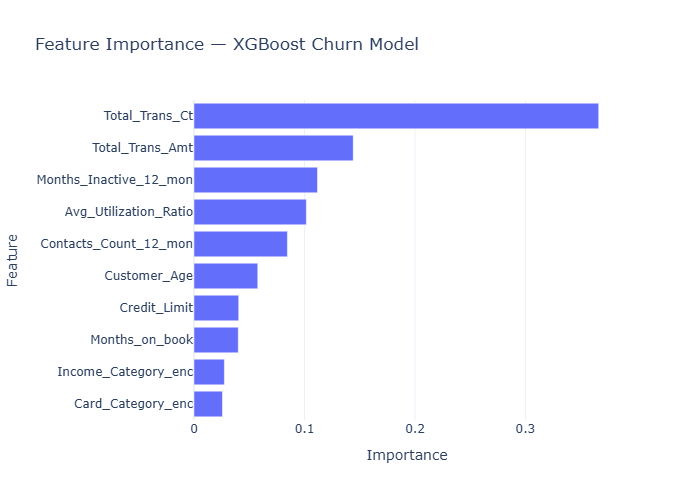

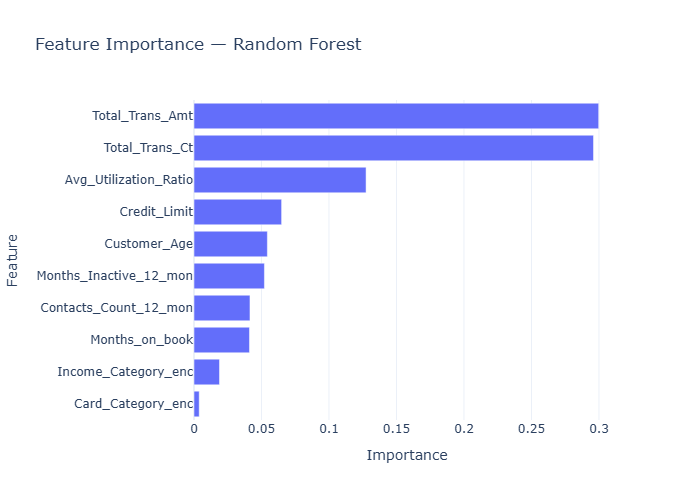

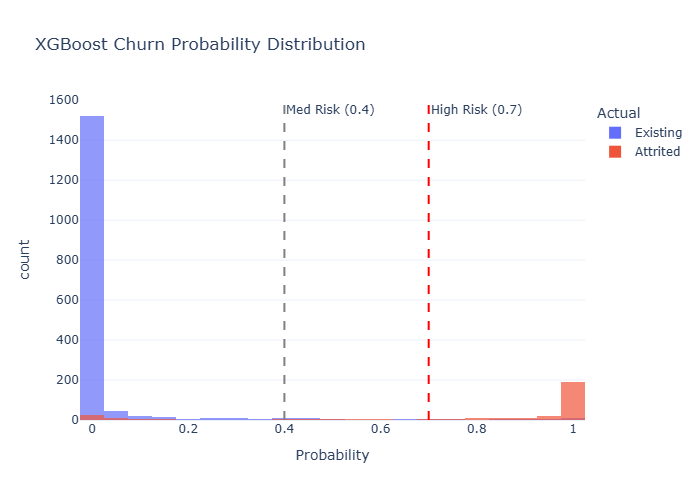

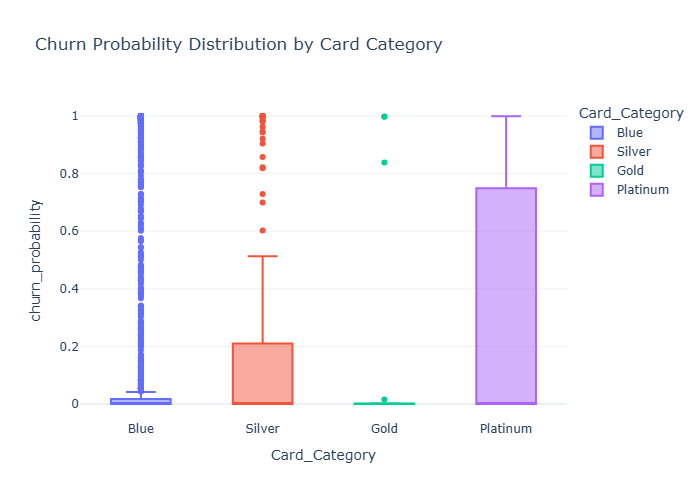

In [5]:
# ── Visualizations (Part 2: Feature Importance & Probs) ──────────────────
xgb_fi = pd.Series(xgb.feature_importances_, index=feature_cols_enc).sort_values()
fig3 = px.bar(x=xgb_fi.values, y=xgb_fi.index, orientation='h', title="Feature Importance — XGBoost Churn Model")
fig3.update_layout(template='plotly_white', xaxis_title='Importance', yaxis_title='Feature')
fig3.show()

rf_fi = pd.Series(rf.feature_importances_, index=feature_cols_enc).sort_values()
fig4 = px.bar(x=rf_fi.values, y=rf_fi.index, orientation='h', title="Feature Importance — Random Forest")
fig4.update_layout(template='plotly_white', xaxis_title='Importance', yaxis_title='Feature')
fig4.show()

prob_df = pd.DataFrame({'Probability': results['XGBoost']['prob'], 'Actual': y_test.map({0:'Existing', 1:'Attrited'})})
fig5 = px.histogram(prob_df, x='Probability', color='Actual', nbins=20, title="XGBoost Churn Probability Distribution", barmode='overlay', opacity=0.7)
fig5.add_vline(x=0.4, line_dash="dash", line_color="gray", annotation_text="Med Risk (0.4)")
fig5.add_vline(x=0.7, line_dash="dash", line_color="red", annotation_text="High Risk (0.7)")
fig5.update_layout(template='plotly_white')
fig5.show()

test_full = df.loc[X_test.index].copy()
test_full['churn_probability'] = results['XGBoost']['prob']
fig8 = px.box(test_full, x='Card_Category', y='churn_probability', color='Card_Category', title="Churn Probability Distribution by Card Category")
fig8.update_layout(template='plotly_white')
fig8.show()

In [6]:
# ── Save Predictions & Models ─────────────────────────────────────────
df_test = X_test.copy()
df_test['CLIENTNUM'] = df.loc[X_test.index, 'CLIENTNUM'].values
df_test['actual_churn'] = y_test.values
df_test['churn_probability'] = results['XGBoost']['prob']
df_test['risk_label'] = pd.cut(
    df_test['churn_probability'],
    bins=[-0.01, 0.4, 0.7, 1.01],
    labels=['Loyal', 'Medium Risk', 'High Risk']
)
df_test.to_csv('../../data/processed/churn_predictions.csv', index=False)

import joblib, os
os.makedirs('../../models/churn', exist_ok=True)
joblib.dump(lr, '../../models/churn/logistic_regression.pkl')
joblib.dump(rf, '../../models/churn/random_forest.pkl')
joblib.dump(xgb, '../../models/churn/xgboost_model.pkl')
joblib.dump(le_income, '../../models/churn/le_income.pkl')
joblib.dump(le_card, '../../models/churn/le_card.pkl')

print("=== FINAL REAL MODEL RESULTS ===")
for name, res in results.items():
    print(f"{name}: Accuracy={res['accuracy']:.4f}, F1={res['f1']:.4f}, AUC={res['auc']:.4f}")
print(f"\nTop 5 most-at-risk customers:")
print(df_test.nlargest(5, 'churn_probability')[['CLIENTNUM','churn_probability','risk_label']].to_string(index=False))

=== FINAL REAL MODEL RESULTS ===
Logistic Regression: Accuracy=0.7937, F1=0.5457, AUC=0.8740
Random Forest: Accuracy=0.9378, F1=0.7850, AUC=0.9745
XGBoost: Accuracy=0.9501, F1=0.8414, AUC=0.9745

Top 5 most-at-risk customers:
 CLIENTNUM  churn_probability risk_label
 772073508             1.0000  High Risk
 720551733             1.0000  High Risk
 809849358             1.0000  High Risk
 713027058             1.0000  High Risk
 809811858             1.0000  High Risk
